---
### **IMPORTS**
---

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict

---
### **DATA LOADING & CLEANING**
---

In [30]:
MODEL_CLASSES = ['Kids_0_6m', 'Weanlings_6_12m', 'Adults_12_plus']

In [31]:
def _clean_numeric_series(s: pd.Series) -> pd.Series:
    return (
        s.astype(str)
         .str.replace(',', '', regex=False)
         .str.replace('"', '', regex=False)
         .pipe(pd.to_numeric, errors='coerce')
         .fillna(0)
    )


def load_knbs(filepath: str) -> pd.DataFrame:
    """Load KNBS population CSV, keep meat goats only, clean numerics."""
    df = pd.read_csv(filepath, usecols=['Year', 'County', 'Region', 'Goats_Meat'])
    df['Goats_Meat'] = _clean_numeric_series(df['Goats_Meat']).astype(int)
    df['Year'] = pd.to_numeric(df['Year'], errors='coerce').dropna().astype(int)
    df = df.dropna(subset=['Year'])
    return df


def knbs_national(filepath: str) -> pd.DataFrame:
    """Return national totals for meat goats by Year (sorted)."""
    df = load_knbs(filepath)
    nat = df.groupby('Year', as_index=False)['Goats_Meat'].sum().sort_values('Year')
    return nat


def load_knbs_production(filepath: str) -> pd.DataFrame:
    """Load KNBS production data (chevon_kg) if available, cleaned."""
    try:
        prod = pd.read_csv(filepath)
    except Exception:
        return pd.DataFrame()
    prod = prod.rename(columns={c: c.strip() for c in prod.columns})
    keep_cols = ['year', 'county', 'region', 'chevon_kg']
    prod = prod[[c for c in keep_cols if c in prod.columns]]
    if 'chevon_kg' in prod.columns:
        prod['chevon_kg'] = _clean_numeric_series(prod['chevon_kg']).astype(float)
    return prod.sort_values(['year', 'county']) if not prod.empty else prod


def load_kiamis(filepath: str) -> pd.DataFrame:
    """Load KIAMIS, keep only meat goats and normalize age labels + numeric counts."""
    df = pd.read_csv(filepath)
    df = df[df.get("livestock_sub_category", "") == "Meat goats (Chevon)"].copy()

    def norm_age(s: str) -> str:
        s = str(s).strip().lower()
        s = s.replace("years", "yrs").replace("year", "yr")
        s = s.replace("months", "mo").replace("month", "mo")
        s = s.replace("weeks", "wk").replace("week", "wk")
        s = s.replace("less than", "<")
        s = s.replace("yrs", "yr").replace(" ", "")
        s = s.replace("orolder", "+")
        s = s.replace("to", "-").replace(" - ", "-")
        return s

    df["age_norm"] = df["livestock_age"].astype(str).map(norm_age)
    for col in ["male_livestock_count", "female_livestock_count", "total_livestock_count"]:
        if col in df.columns:
            df[col] = _clean_numeric_series(df[col]).astype(int)
    return df


def compute_overall_kiamis_props(kiam_df: pd.DataFrame) -> Dict[str, Dict[str, float]]:
    mapping = {
        'lessthan2months': 'Kids_0_6m', '0-2months': 'Kids_0_6m', '2-6months': 'Kids_0_6m',
        '3-8weeks': 'Kids_0_6m', '0-6months': 'Kids_0_6m',
        '6-12months': 'Weanlings_6_12m', '6-12m': 'Weanlings_6_12m', '6-12': 'Weanlings_6_12m',
        '1-2years': 'Adults_12_plus', '1-2yrs': 'Adults_12_plus', '1-2yr': 'Adults_12_plus', '12-24months': 'Adults_12_plus',
        '2-4yrs': 'Adults_12_plus', '2-4years': 'Adults_12_plus', '24-48months': 'Adults_12_plus',
        '4yrsorolder': 'Adults_12_plus', '4-6yrs': 'Adults_12_plus', '4-5yrs': 'Adults_12_plus', '5-6yrs': 'Adults_12_plus', '4+yrs': 'Adults_12_plus'
    }
    tmp = kiam_df.copy()
    tmp['model_class'] = tmp['age_norm'].map(mapping)
    tmp = tmp.dropna(subset=['model_class'])
    if tmp.empty:
        return {cls: {'prop_total': 1.0 / len(MODEL_CLASSES), 'prop_female': 0.5, 'prop_male': 0.5} for cls in MODEL_CLASSES}

    grouped = tmp.groupby('model_class', as_index=False).agg(
        male=('male_livestock_count', 'sum'),
        female=('female_livestock_count', 'sum'),
        total=('total_livestock_count', 'sum')
    )
    grand = grouped['total'].sum() if grouped['total'].sum() > 0 else 1.0
    out = {}
    for _, r in grouped.iterrows():
        out[r['model_class']] = {
            'prop_total': float(r['total'] / grand),
            'prop_female': float(r['female'] / r['total']) if r['total'] > 0 else 0.5,
            'prop_male': float(r['male'] / r['total']) if r['total'] > 0 else 0.5
        }
    for cls in MODEL_CLASSES:
        out.setdefault(cls, {'prop_total': 1.0 / len(MODEL_CLASSES), 'prop_female': 0.5, 'prop_male': 0.5})
    return out

---
### **BUILD A STRUCTURED 2023 BASELINE (STATE VECTOR)**
---

In [32]:
def build_structured_knbs_all_years(knbs_nat: pd.DataFrame,
                                   overall_kiamis_props: Dict,
                                   rounding: bool = True) -> pd.DataFrame:
    rows = []
    for _, r in knbs_nat.iterrows():
        y = int(r['Year'])
        total = int(round(r['Goats_Meat']))
        out = {'Year': y, 'Goats_Meat': total}
        props = overall_kiamis_props or {cls: {'prop_total': 1.0 / len(MODEL_CLASSES), 'prop_female': 0.5, 'prop_male': 0.5} for cls in MODEL_CLASSES}
        for cls in MODEL_CLASSES:
            p_total = float(props.get(cls, {}).get('prop_total', 0.0))
            p_f = float(props.get(cls, {}).get('prop_female', 0.5))
            p_m = float(props.get(cls, {}).get('prop_male', 0.5))
            n_cls = total * p_total
            if rounding:
                n_cls = int(round(n_cls))
                n_f = int(round(n_cls * p_f))
                n_m = int(round(n_cls * p_m))
            else:
                n_f = n_cls * p_f
                n_m = n_cls * p_m
            out[f'{cls}_female'] = n_f
            out[f'{cls}_male'] = n_m
        rows.append(out)
    structured_hist = pd.DataFrame(rows).sort_values('Year').reset_index(drop=True)
    return structured_hist


def _normalize_structured_hist(df: pd.DataFrame) -> pd.DataFrame:
    """Normalize per-row summed age-class counts to match Goats_Meat (keeps integer counts)."""
    out = df.copy()
    for i, r in out.iterrows():
        class_sum = sum(r.get(f'{cls}_female', 0) + r.get(f'{cls}_male', 0) for cls in MODEL_CLASSES)
        target = float(r.get('Goats_Meat', class_sum)) or class_sum
        if class_sum > 0 and target != class_sum:
            factor = target / class_sum
            for cls in MODEL_CLASSES:
                out.at[i, f'{cls}_female'] = int(round(r.get(f'{cls}_female', 0) * factor))
                out.at[i, f'{cls}_male'] = int(round(r.get(f'{cls}_male', 0) * factor))
    return out


def estimate_repro_status(structured_row: pd.Series, params: Dict) -> Dict[str, float]:
    repro_classes = params['reproductive_classes']
    breed_frac = params['breeding_fraction']
    repro_females = sum(float(structured_row.get(f'{cls}_female', 0.0)) * float(breed_frac.get(cls, 1.0)) for cls in repro_classes)
    cycle_days = 365.0 / max(1e-6, params['kidding_rate'])
    preg_prop = min(0.95, params['gestation_days'] / cycle_days)
    pregnant_does = repro_females * preg_prop
    lactating_does = repro_females * float(params['lactating_prop'])
    return {'pregnant_does': float(pregnant_does), 'lactating_does': float(lactating_does)}

---
### **MODEL PARAMETERS**
---

In [33]:
def get_model_params() -> Dict:
    """
    Defines model parameters for Kenyan meat goats.
    Values are tuned for initial growth that slows over time (logarithmic-like).
    """
    return {
        # --- Reproductive Parameters ---
        # High initial birth rate to kickstart growth before density effects apply.
        'kidding_rate': 1.5,  # Avg. kiddings per breeding doe per year.
        'litter_size': 1.7,  # Avg. kids per kidding.
        'sex_ratio_at_birth': 0.51, # Proportion of male births.
        'gestation_days': 150,
        'breeding_fraction': {
            'Kids_0_6m': 0.0,
            'Weanlings_6_12m': 0.15,
            'Adults_12_plus': 0.90
        },
        'reproductive_classes': ['Weanlings_6_12m', 'Adults_12_plus'],

        # --- Mortality and Offtake Rates (Annual) ---
        'kid_mortality_0_6m': 0.18, # Mortality for the youngest cohort.
        'kid_mortality_6_12m': 0.08, # Mortality for weanlings.
        'adult_mortality': 0.05, # Mortality for adults.
        'offtake_rates': {
            'Kids_0_6m': 0.01,
            'Weanlings_6_12m': 0.15,
            'Adults_12_plus': 0.20
        },
        'annual_doe_culling_rate': 0.03, # Additional removal of adult females.

        # --- Production Parameters (Meat & Milk) ---
        'lactating_prop': 0.80,
        'milk_yield_per_day': 0.4, # Low yield for meat-focused goats.
        'lactation_days': 90, # Shorter lactation period.
        'avg_weights': {
            'Kids_0_6m': 10,
            'Weanlings_6_12m': 20,
            'Adults_12_plus': 38
        },
        'carcass_yield': {
            'Kids_0_6m': 0.47,
            'Weanlings_6_12m': 0.49,
            'Adults_12_plus': 0.51
        },

        # --- Feed & Management ---
        'dmi_pct': {
            'Kids_0_6m': 0.045,
            'Weanlings_6_12m': 0.040,
            'Adults_12_plus': 0.035
        },
        'does_per_buck': 25,
    }

In [34]:
def project_population(state: pd.Series, params: Dict, years: int = 10, start_year: int = 2024) -> pd.DataFrame:
    """Projects population with density-dependent (logarithmic-like) growth."""

    # --- Unpack parameters for readability ---
    kidding_rate = params.get('kidding_rate', 1.5)
    litter_size = params.get('litter_size', 1.7)
    sex_ratio = params.get('sex_ratio_at_birth', 0.51)
    breeding_frac = params.get('breeding_fraction', {})
    repro_classes = params.get('reproductive_classes', ['Adults_12_plus'])

    # Production params
    lact_prop = params.get('lactating_prop', 0.8)
    milk_yield = params.get('milk_yield_per_day', 0.4)
    lact_days = params.get('lactation_days', 90)

    # Survival and offtake params
    offtake = params.get('offtake_rates', {})
    kid_mort_0_6 = params.get('kid_mortality_0_6m', 0.18)
    kid_mort_6_12 = params.get('kid_mortality_6_12m', 0.08)
    adult_mort = params.get('adult_mortality', 0.05)
    cull_rate = params.get('annual_doe_culling_rate', 0.03)

    projections = []
    current_state = {k: float(v) for k, v in state.to_dict().items()}

    # --- Density-Dependence Setup ---
    # Set a population ceiling based on the initial state to slow growth over time.
    # This is not a new parameter, but a dynamic variable for achieving logarithmic shape.
    initial_total_pop = sum(v for k, v in current_state.items() if isinstance(v, (int, float)))
    population_ceiling = initial_total_pop * 1.75

    def calculate_production_metrics(state_dict, removed_meat=0.0):
        total_pop = sum(state_dict.get(f'{cls}_female', 0.0) + state_dict.get(f'{cls}_male', 0.0)
                          for cls in MODEL_CLASSES)
        repro_females = sum(state_dict.get(f'{cls}_female', 0.0) * breeding_frac.get(cls, 0.0)
                              for cls in repro_classes)
        lactating_does = repro_females * lact_prop
        milk_production = lactating_does * milk_yield * lact_days
        feed_required = sum((state_dict.get(f'{cls}_female', 0.0) + state_dict.get(f'{cls}_male', 0.0)) *
                            params['avg_weights'][cls] * params['dmi_pct'][cls] * 365.0
                            for cls in MODEL_CLASSES)
        return {
            'total_population': total_pop,
            'milk_liters': milk_production,
            'meat_kg': removed_meat,
            'feed_kg': feed_required,
            'lactating_does': lactating_does,
            'pregnant_does': repro_females * (params.get('gestation_days', 150) / 365.0)
        }

    # Baseline Year (e.g., 2023)
    baseline_metrics = calculate_production_metrics(current_state)
    baseline_row = {'Year': start_year - 1, **current_state, **baseline_metrics}
    projections.append(baseline_row)

    # --- Projection Loop ---
    for year_idx in range(years + 1):
        current_year = start_year + year_idx
        prev_state = current_state.copy()
        next_state = {f'{cls}_{sex}': 0.0 for cls in MODEL_CLASSES for sex in ['female', 'male']}
        total_meat_produced = 0.0
        
        current_total_pop = sum(v for k, v in prev_state.items() if isinstance(v, (int, float)))
        pressure_factor = min(1.0, current_total_pop / population_ceiling)

        # Step 1: Calculate Births, reduced by the pressure factor to cause growth to slow down.
        repro_females = sum(prev_state.get(f'{cls}_female', 0.0) * breeding_frac.get(cls, 0.0)
                              for cls in repro_classes)
        effective_birth_rate_modifier = max(0.0, 1.0 - pressure_factor)
        total_births = repro_females * kidding_rate * litter_size * effective_birth_rate_modifier
        
        next_state['Kids_0_6m_female'] = total_births * (1.0 - sex_ratio)
        next_state['Kids_0_6m_male'] = total_births * sex_ratio

        # Step 2: Age cohorts, applying mortality and offtake to calculate transitions.
        # Kids -> Weanlings
        kids_f, kids_m = prev_state.get('Kids_0_6m_female', 0), prev_state.get('Kids_0_6m_male', 0)
        surv_kids_f = kids_f * (1.0 - kid_mort_0_6 - offtake.get('Kids_0_6m', 0))
        surv_kids_m = kids_m * (1.0 - kid_mort_0_6 - offtake.get('Kids_0_6m', 0))
        next_state['Weanlings_6_12m_female'] = max(0, surv_kids_f)
        next_state['Weanlings_6_12m_male'] = max(0, surv_kids_m)
        total_meat_produced += (kids_f + kids_m) * offtake.get('Kids_0_6m', 0) * params['avg_weights']['Kids_0_6m'] * params['carcass_yield']['Kids_0_6m']
        
        # Weanlings -> Adults
        wean_f, wean_m = prev_state.get('Weanlings_6_12m_female', 0), prev_state.get('Weanlings_6_12m_male', 0)
        surv_wean_f = wean_f * (1.0 - kid_mort_6_12 - offtake.get('Weanlings_6_12m', 0))
        surv_wean_m = wean_m * (1.0 - kid_mort_6_12 - offtake.get('Weanlings_6_12m', 0))
        next_state['Adults_12_plus_female'] += max(0, surv_wean_f)
        next_state['Adults_12_plus_male'] += max(0, surv_wean_m)
        total_meat_produced += (wean_f + wean_m) * offtake.get('Weanlings_6_12m', 0) * params['avg_weights']['Weanlings_6_12m'] * params['carcass_yield']['Weanlings_6_12m']

        # Adults -> Adults (surviving)
        adults_f, adults_m = prev_state.get('Adults_12_plus_female', 0), prev_state.get('Adults_12_plus_male', 0)
        culled_f = adults_f * cull_rate
        remaining_adults_f = adults_f - culled_f
        surv_adults_f = remaining_adults_f * (1.0 - adult_mort - offtake.get('Adults_12_plus', 0))
        surv_adults_m = adults_m * (1.0 - adult_mort - offtake.get('Adults_12_plus', 0))
        next_state['Adults_12_plus_female'] += max(0, surv_adults_f)
        next_state['Adults_12_plus_male'] += max(0, surv_adults_m)
        
        adult_offtake_count = (remaining_adults_f + adults_m) * offtake.get('Adults_12_plus', 0) + culled_f
        total_meat_produced += adult_offtake_count * params['avg_weights']['Adults_12_plus'] * params['carcass_yield']['Adults_12_plus']
        
        # Step 3: Finalize and record the state for the current projected year
        year_metrics = calculate_production_metrics(next_state, total_meat_produced)
        year_row = {'Year': current_year, **next_state, **year_metrics}
        projections.append(year_row)
        
        current_state = next_state.copy()

    proj_df = pd.DataFrame(projections).sort_values('Year').reset_index(drop=True)
    proj_df = proj_df[proj_df['Year'] >= start_year - 1].reset_index(drop=True)
    return proj_df

In [35]:
def compute_historical_milk_and_feed(structured_hist: pd.DataFrame, params: Dict) -> pd.DataFrame:
    rows = []
    for _, r in structured_hist.iterrows():
        year = int(r['Year'])
        repro_females = sum(r.get(f'{cls}_female', 0.0) * params['breeding_fraction'].get(cls, 1.0) for cls in params['reproductive_classes'])
        lactating_does = repro_females * params['lactating_prop']
        milk_liters = lactating_does * params['milk_yield_per_day'] * params['lactation_days']
        feed_kg = sum((r.get(f'{cls}_female', 0.0) + r.get(f'{cls}_male', 0.0)) * params['avg_weights'][cls] * params['dmi_pct'][cls] * 365.0 for cls in MODEL_CLASSES)
        rows.append({'Year': year, 'lactating_does': lactating_does, 'milk_liters': milk_liters, 'feed_kg': feed_kg})
    return pd.DataFrame(rows).sort_values('Year')

---
### **VISUALIZATION**
---

In [36]:
def plot_history_vs_projection(knbs_nat: pd.DataFrame, projections: pd.DataFrame):
    plt.figure(figsize=(7,5))
    plt.plot(knbs_nat['Year'], knbs_nat['Goats_Meat'], 'o--', label='KNBS (historical)')
    plt.plot(projections['Year'], projections['total_population'], 'o-', label='Projection')
    plt.title('Total Population: Historical vs Projection')
    plt.xlabel('Year'); plt.ylabel('Population'); plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()


def plot_production(projections: pd.DataFrame):
    fig, axes = plt.subplots(1,3, figsize=(15,4))
    axes[0].plot(projections['Year'], projections['milk_liters'], 'o-'); axes[0].set_title('Milk Production'); axes[0].set_xlabel('Year'); axes[0].set_ylabel('Liters'); axes[0].grid(True)
    axes[1].plot(projections['Year'], projections['meat_kg'], 'o-'); axes[1].set_title('Meat Production'); axes[1].set_xlabel('Year'); axes[1].set_ylabel('Kg'); axes[1].grid(True)
    axes[2].plot(projections['Year'], projections['feed_kg'], 'o-'); axes[2].set_title('Feed Requirements'); axes[2].set_xlabel('Year'); axes[2].set_ylabel('Kg'); axes[2].grid(True)
    plt.tight_layout(); plt.show()


def plot_age_classes(projections: pd.DataFrame):
    fig, axes = plt.subplots(1, len(MODEL_CLASSES), figsize=(6*len(MODEL_CLASSES),4))
    if len(MODEL_CLASSES) == 1:
        axes = [axes]
    for i, cls in enumerate(MODEL_CLASSES):
        ax = axes[i]
        ax.plot(projections['Year'], projections[f'{cls}_female'], label='Female')
        ax.plot(projections['Year'], projections[f'{cls}_male'], label='Male')
        ax.set_title(cls.replace('_',' ').replace('Kids','Kids'))
        ax.set_xlabel('Year'); ax.set_ylabel('Population'); ax.grid(True); ax.legend()
    plt.tight_layout(); plt.show()

In [37]:
def export_to_excel_final(knbs_nat: pd.DataFrame,
                          structured_hist: pd.DataFrame,
                          historical_prod_knbs: pd.DataFrame,
                          historical_milk_feed: pd.DataFrame,
                          projections: pd.DataFrame,
                          overall_kiamis_props: Dict,
                          params: Dict,
                          filename: str = "goat_population_results.xlsx"):
    """Export results into Excel using the combined sheet spec (keeps same sheet names)."""
    with pd.ExcelWriter(filename, engine='openpyxl') as writer:
        knbs_nat.to_excel(writer, sheet_name='Historical_KNBS_National', index=False)
        structured_hist.to_excel(writer, sheet_name='Historical_Age_Structure', index=False)

        if overall_kiamis_props:
            rows = [{'model_class': cls, 'prop_total': p['prop_total'], 'prop_female': p['prop_female'], 'prop_male': p['prop_male']} for cls, p in overall_kiamis_props.items()]
            pd.DataFrame(rows).to_excel(writer, sheet_name='KIAMIS_Overall_Proportions', index=False)

        if historical_prod_knbs is not None and not historical_prod_knbs.empty:
            historical_prod_knbs.to_excel(writer, sheet_name='Historical_Meat_Production', index=False)

        historical_milk_feed.to_excel(writer, sheet_name='Historical_Milk_Feed', index=False)
        projections.to_excel(writer, sheet_name='Projections_Data', index=False)

        # combined timeline & summaries
        hist_pop = knbs_nat.rename(columns={'Year':'Year','Goats_Meat':'total_population_Historical'})[['Year','total_population_Historical']]
        hist_milk_feed = historical_milk_feed.rename(columns={'Year':'Year','milk_liters':'milk_liters_Historical','feed_kg':'feed_kg_Historical'})[['Year','milk_liters_Historical','feed_kg_Historical']].drop_duplicates(subset=['Year'])
        hist_meat = None
        if historical_prod_knbs is not None and 'year' in historical_prod_knbs.columns and 'chevon_kg' in historical_prod_knbs.columns:
            hist_meat = historical_prod_knbs.groupby('year', as_index=False)['chevon_kg'].sum().rename(columns={'year':'Year','chevon_kg':'meat_kg_Historical'})

        proj_pop = projections[['Year','total_population']].rename(columns={'total_population':'total_population_Forecasted'})
        proj_prod = projections[['Year','milk_liters','meat_kg','feed_kg']].rename(columns={'milk_liters':'milk_liters_Forecasted','meat_kg':'meat_kg_Forecasted','feed_kg':'feed_kg_Forecasted'})

        structured_totals_hist = pd.DataFrame({
            'Year': structured_hist['Year'],
            'Total_Kids_Historical': (structured_hist.get('Kids_0_6m_female',0) + structured_hist.get('Kids_0_6m_male',0)).astype(float),
            'Total_Weanlings_Historical': (structured_hist.get('Weanlings_6_12m_female',0) + structured_hist.get('Weanlings_6_12m_male',0)).astype(float),
            'Total_Adults_Historical': (structured_hist.get('Adults_12_plus_female',0) + structured_hist.get('Adults_12_plus_male',0)).astype(float)
        })

        structured_totals_proj = pd.DataFrame({
            'Year': projections['Year'],
            'Total_Kids_Forecasted': (projections.get('Kids_0_6m_female',0) + projections.get('Kids_0_6m_male',0)).astype(float),
            'Total_Weanlings_Forecasted': (projections.get('Weanlings_6_12m_female',0) + projections.get('Weanlings_6_12m_male',0)).astype(float),
            'Total_Adults_Forecasted': (projections.get('Adults_12_plus_female',0) + projections.get('Adults_12_plus_male',0)).astype(float)
        })

        all_years = sorted(set(list(hist_pop['Year'].astype(int).tolist()) + list(proj_pop['Year'].astype(int).tolist())))
        combined = pd.DataFrame({'Year': all_years})
        combined = combined.merge(hist_pop, on='Year', how='left')
        combined = combined.merge(proj_pop, on='Year', how='left')
        combined = combined.merge(hist_milk_feed, on='Year', how='left')
        if hist_meat is not None:
            combined = combined.merge(hist_meat[['Year','meat_kg_Historical']], on='Year', how='left')
        else:
            combined['meat_kg_Historical'] = np.nan
        combined = combined.merge(proj_prod, on='Year', how='left')
        combined = combined.merge(structured_totals_hist, on='Year', how='left')
        combined = combined.merge(structured_totals_proj, on='Year', how='left')
        combined = combined.loc[:, ~combined.columns.duplicated()]

        final_cols = [
            'Year',
            'total_population_Historical',
            'total_population_Forecasted',
            'milk_liters_Historical',
            'milk_liters_Forecasted',
            'meat_kg_Historical',
            'meat_kg_Forecasted',
            'feed_kg_Historical',
            'feed_kg_Forecasted',
            'Total_Kids_Historical',
            'Total_Kids_Forecasted',
            'Total_Weanlings_Historical',
            'Total_Weanlings_Forecasted',
            'Total_Adults_Historical',
            'Total_Adults_Forecasted'
        ]
        for c in final_cols:
            if c not in combined.columns:
                combined[c] = np.nan
        combined = combined[final_cols]
        combined.to_excel(writer, sheet_name='Combined_Timeline', index=False)

        baseline_year = int(structured_hist['Year'].min())
        demographics_summary = pd.DataFrame({
            'Age_Class': MODEL_CLASSES,
            'Female_Start': [structured_hist[structured_hist['Year']==baseline_year].iloc[0].get(f'{cls}_female', 0) for cls in MODEL_CLASSES],
            'Male_Start': [structured_hist[structured_hist['Year']==baseline_year].iloc[0].get(f'{cls}_male', 0) for cls in MODEL_CLASSES],
            'Female_End': [projections.iloc[-1].get(f'{cls}_female', 0) for cls in MODEL_CLASSES],
            'Male_End': [projections.iloc[-1].get(f'{cls}_male', 0) for cls in MODEL_CLASSES]
        })
        demographics_summary.to_excel(writer, sheet_name='Demographics_Summary', index=False)

        production_summary = pd.DataFrame({
            'Production_Type': ['Milk', 'Meat', 'Feed Required'],
            'Start_Year_Value': [
                combined['milk_liters_Historical'].dropna().iloc[-1] if combined['milk_liters_Historical'].notna().any() else projections.iloc[0]['milk_liters'],
                combined['meat_kg_Historical'].dropna().iloc[-1] if combined['meat_kg_Historical'].notna().any() else projections.iloc[0]['meat_kg'],
                combined['feed_kg_Historical'].dropna().iloc[-1] if combined['feed_kg_Historical'].notna().any() else projections.iloc[0]['feed_kg']
            ],
            'End_Year_Value': [projections.iloc[-1]['milk_liters'], projections.iloc[-1]['meat_kg'], projections.iloc[-1]['feed_kg']],
            'Units': ['Liters','Kg','Kg']
        })
        production_summary['Growth_%'] = production_summary.apply(
            lambda r: ((r['End_Year_Value'] / (r['Start_Year_Value'] if r['Start_Year_Value'] and r['Start_Year_Value']>0 else 1)) - 1) * 100, axis=1)
        production_summary.to_excel(writer, sheet_name='Production_Summary', index=False)

        params_df = pd.DataFrame({'Parameter': list(params.keys()), 'Value': [str(v) for v in params.values()]})
        params_df.to_excel(writer, sheet_name='Model_Parameters', index=False)

        start_pop = structured_hist[structured_hist['Year']==baseline_year].iloc[0]['Goats_Meat']
        end_pop = projections.iloc[-1]['total_population']
        summary_stats = pd.DataFrame({
            'Metric': ['Historical Period', 'Projection Period', 'Starting Population', 'Ending Population', 'Total Growth %', 'Annual Growth Rate %'],
            'Value': [
                f"{knbs_nat['Year'].min()}-{knbs_nat['Year'].max()}",
                f"{projections['Year'].min()}-{projections['Year'].max()}",
                f"{start_pop:,.0f}", f"{end_pop:,.0f}",
                f"{((end_pop / start_pop) - 1) * 100:.1f}%" if start_pop>0 else "N/A",
                f"{(((end_pop / start_pop) ** (1/len(projections))) - 1) * 100:.1f}%" if (start_pop>0 and len(projections)>0) else "N/A"
            ]
        })
        summary_stats.to_excel(writer, sheet_name='Summary', index=False)

    print(f"✓ Results exported to Excel: {filename}")


---
### **MODEL OUTPUTS**
---

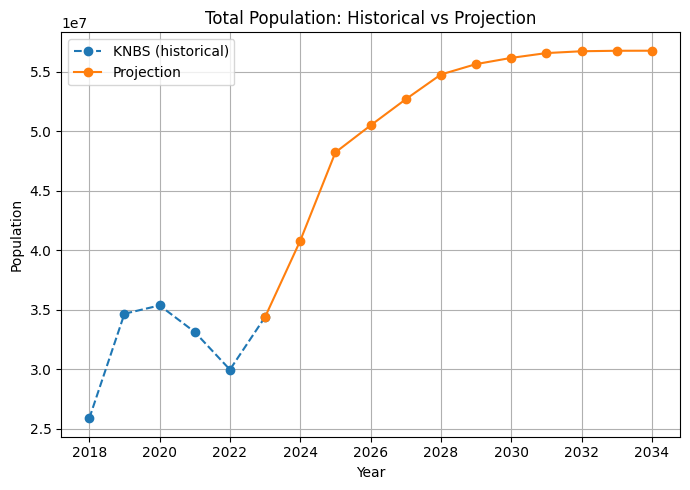

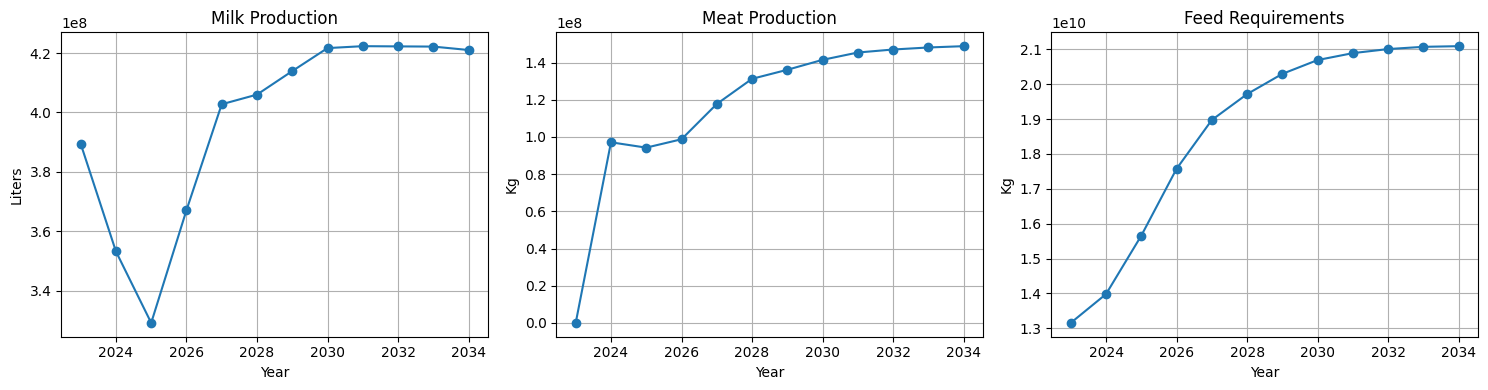

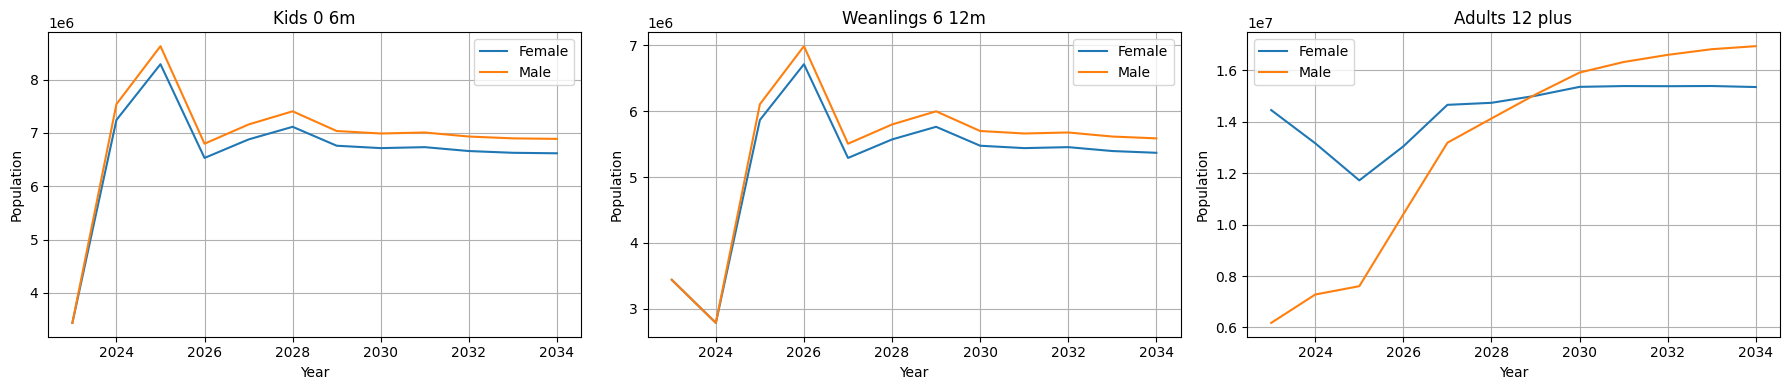

In [38]:
if __name__ == "__main__":
    # --- file paths ---
    KNBS_CSV   = "data/knbs_population.csv"
    KIAMIS_CSV = "data/kiamis_livestock.csv"
    KNBS_PROD_CSV = "data/knbs_production.csv"
    BASELINE_YEAR = 2023
    YEARS_AHEAD = 10

    # A) load & prep data
    knbs_nat = knbs_national(KNBS_CSV)
    kiam_raw = load_kiamis(KIAMIS_CSV)
    overall_kiamis_props = compute_overall_kiamis_props(kiam_raw)

    # B) build structured historical (per KNBS year) using overall KIAMIS proportions
    structured_hist = build_structured_knbs_all_years(knbs_nat, overall_kiamis_props, rounding=True)

    # C) normalize class counts to match Goats_Meat
    structured_hist = _normalize_structured_hist(structured_hist)

    # Use 2023 census counts to create stable-age initialization
    baseline_row = structured_hist[structured_hist['Year'] == 2023].iloc[0]

    params = get_model_params()

    state_2023 = pd.Series(dtype=float)
    for cls in MODEL_CLASSES:
        state_2023[f'{cls}_female'] = float(baseline_row[f'{cls}_female'])
        state_2023[f'{cls}_male'] = float(baseline_row[f'{cls}_male'])

    repro_females = sum(state_2023.get(f'{cls}_female', 0.0) * params['breeding_fraction'].get(cls, 1.0)
                        for cls in params['reproductive_classes'])
    state_2023['Pregnant_does'] = repro_females * (params.get('gestation_days', 150) / 365.0)
    state_2023['Lactating_does'] = repro_females * params.get('lactating_prop', 0.58)

    # D) project (start projection in 2024 using the stable 2023-derived state)
    BASELINE_YEAR = 2024
    projections = project_population(state_2023, params, years=YEARS_AHEAD, start_year=BASELINE_YEAR)

    # E) historical production data: load KNBS production file if available
    try:
        historical_prod_knbs = load_knbs_production(KNBS_PROD_CSV)
    except Exception as e:
        print(f"Could not load KNBS production file '{KNBS_PROD_CSV}': {e}")
        historical_prod_knbs = pd.DataFrame()

    # compute historical milk & feed estimates from structured_hist
    historical_milk_feed = compute_historical_milk_and_feed(structured_hist, params)

    # F) plots
    plot_history_vs_projection(knbs_nat, projections)
    plot_production(projections)
    plot_age_classes(projections)

    # G) export
    # export_to_excel_final(knbs_nat=knbs_nat,
    #                       structured_hist=structured_hist,
    #                       historical_prod_knbs=historical_prod_knbs,
    #                       historical_milk_feed=historical_milk_feed,
    #                       projections=projections,
    #                       overall_kiamis_props=overall_kiamis_props,
    #                       params=params,
    #                       filename="goat_population_results.xlsx")

In [39]:
historical_milk_feed

,Year,lactating_does,milk_liters,feed_kg
0,2018,8141127.48,2.930806e+08,9.898130e+09
1,2019,10904070.84,3.925466e+08,1.325737e+10
2,2020,11124526.44,4.004830e+08,1.352540e+10
3,2021,10421206.20,3.751634e+08,1.267029e+10
4,2022,9427588.32,3.393932e+08,1.146223e+10
5,2023,10818503.28,3.894661e+08,1.315333e+10


In [40]:
projections

,Year,Kids_0_6m_female,Kids_0_6m_male,Weanlings_6_12m_female,Weanlings_6_12m_male,Adults_12_plus_female,Adults_12_plus_male,Pregnant_does,Lactating_does,total_population,milk_liters,meat_kg,feed_kg,lactating_does,pregnant_does
0,2023,3.438600e+06,3.438600e+06,3.438600e+06,3.438600e+06,1.445260e+07,6.179000e+06,5.557450e+06,10818503.28,3.438600e+07,3.894661e+08,0.000000e+00,1.315333e+10,1.081850e+07,5.557450e+06
1,2024,7.241636e+06,7.537213e+06,2.785266e+06,2.785266e+06,1.316199e+07,7.281972e+06,NaN,NaN,4.079334e+07,3.531911e+08,9.712298e+07,1.397854e+10,9.810863e+06,5.039827e+06
2,2025,8.286685e+06,8.624917e+06,5.865725e+06,6.105142e+06,1.172000e+07,7.606134e+06,NaN,NaN,4.820860e+07,3.291224e+08,9.424598e+07,1.565510e+10,9.142288e+06,4.696381e+06
3,2026,6.530045e+06,6.796577e+06,6.712215e+06,6.986183e+06,1.304291e+07,1.040556e+07,NaN,NaN,5.047349e+07,3.670690e+08,9.875132e+07,1.757189e+10,1.019636e+07,5.237856e+06
4,2027,6.876902e+06,7.157592e+06,5.289336e+06,5.505228e+06,1.465712e+07,1.318353e+07,NaN,NaN,5.266971e+07,4.027625e+08,1.177158e+08,1.897242e+10,1.118785e+07,5.747182e+06
5,2028,7.113599e+06,7.403950e+06,5.570291e+06,5.797650e+06,1.473584e+07,1.412667e+07,NaN,NaN,5.474801e+07,4.060168e+08,1.312553e+08,1.971526e+10,1.127824e+07,5.793618e+06
6,2029,6.758960e+06,7.034836e+06,5.762015e+06,5.997200e+06,1.500945e+07,1.505920e+07,NaN,NaN,5.562166e+07,4.139369e+08,1.361183e+08,2.029615e+10,1.149825e+07,5.906634e+06
7,2030,6.714187e+06,6.988235e+06,5.474758e+06,5.698217e+06,1.535613e+07,1.591224e+07,NaN,NaN,5.614376e+07,4.216818e+08,1.414616e+08,2.069236e+10,1.171338e+07,6.017149e+06
8,2031,6.732286e+06,7.007073e+06,5.438491e+06,5.660471e+06,1.538715e+07,1.632181e+07,NaN,NaN,5.654727e+07,4.223291e+08,1.454069e+08,2.089070e+10,1.173136e+07,6.026386e+06
9,2032,6.659392e+06,6.931204e+06,5.453152e+06,5.675729e+06,1.538179e+07,1.659992e+07,NaN,NaN,5.670118e+07,4.222535e+08,1.470220e+08,2.100741e+10,1.172926e+07,6.025307e+06


In [41]:
structured_hist

,Year,Goats_Meat,Kids_0_6m_female,Kids_0_6m_male,Weanlings_6_12m_female,Weanlings_6_12m_male,Adults_12_plus_female,Adults_12_plus_male
0,2018,25876113,2587611,2587611,2587611,2587611,10875853,4649814
1,2019,34657969,3465797,3465797,3465797,3465797,14566910,6227872
2,2020,35358674,3535867,3535867,3535867,3535867,14861420,6353785
3,2021,33123213,3312321,3312321,3312321,3312321,13921844,5952083
4,2022,29965055,2996506,2996506,2996506,2996506,12594455,5384578
5,2023,34385998,3438600,3438600,3438600,3438600,14452599,6179000


Loading historical population data...
Initializing projection from 2023 with total population 34,385,998.
  - Kids_0_6m: 6,877,200
  - Weanlings_6_12m: 8,596,500
  - Adults_12_plus_Does: 9,456,149
  - Adults_12_plus_Bucks: 9,456,149
Combined results saved to 'goat_projection_combined_columns_updated.csv'
Projection results also saved to 'goat_projection_results_updated.csv'

Yearly population & percent change (for diagnostics):
 Year  Total_Pop  Total_Pop_pct_change
 2023   34385998                   NaN
 2024   58928660                 71.37
 2025   68847745                 16.83
 2026   80441314                 16.84
 2027   99781005                 24.04
 2028  120694259                 20.96
 2029  145370162                 20.44
 2030  175867858                 20.98
 2031  212306678                 20.72
 2032  256026346                 20.59
 2033  308753846                 20.59
Plot saved to 'goat_projection_plots_updated.png'


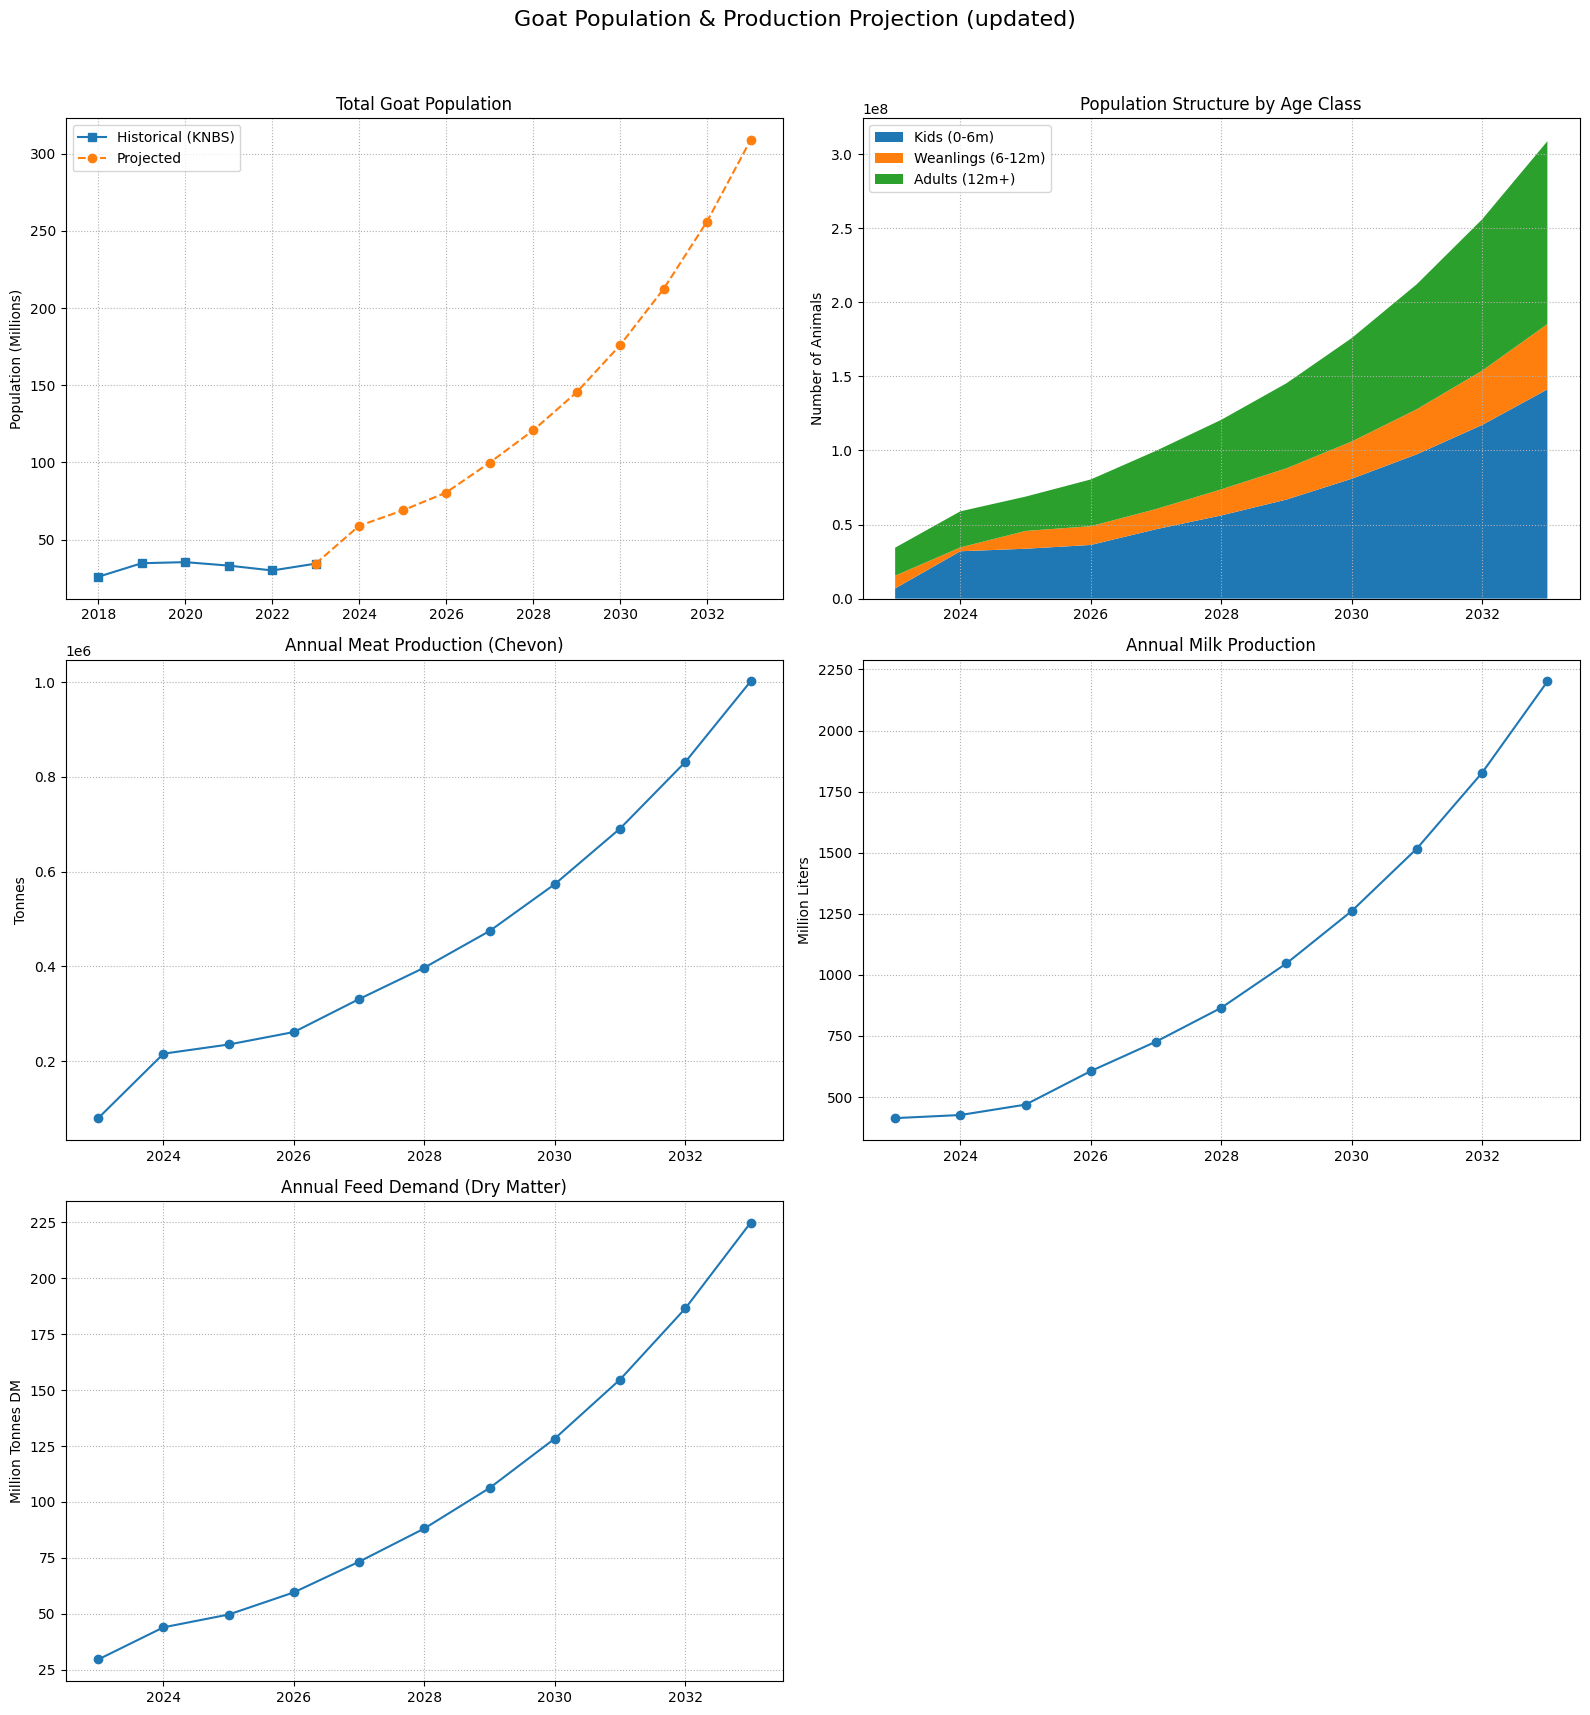

In [1]:
#!/usr/bin/env python3
"""
goat_projection_updated.py

Deterministic yearly goat projection with the following core rules:
- adults split into does & bucks
- age transitions occur BEFORE mortality
- births computed from adult does + female weanlings (female weanlings have half the kidding rate)
- weaned kids (weanlings) have a marketing/offtake rate (sold for meat)
- adult meat comes primarily from doe culls and retained adult removals
- replacement/retention mechanics (doe kid retention, buck retention, doe replacement rate)
- avg_daily_gain used for feed estimates for kids & weanlings
"""

import os
from typing import Dict

import pandas as pd
import matplotlib.pyplot as plt

# --- CONFIG ---
HISTORICAL_DATA_FILE = os.path.join("data", "knbs_population.csv")
START_YEAR_HIST = 2018
PROJECTION_END_YEAR = 2033

# cohort split used to initialize cohorts from a total population scalar
COHORT_SPLIT = {
    "Kids_0_6m": 0.20,
    "Weanlings_6_12m": 0.25,
    "Adults_12_plus": 0.55,
}


# --- UTILITIES ---
def _clean_numeric_series(s: pd.Series) -> pd.Series:
    return (
        s.astype(str)
        .str.replace(",", "", regex=False)
        .str.replace('"', "", regex=False)
        .pipe(pd.to_numeric, errors="coerce")
        .fillna(0)
    )


def load_knbs_national(filepath: str) -> pd.DataFrame:
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"Required file not found: '{filepath}'.")

    df = pd.read_csv(filepath)
    if "Year" not in df.columns or "Goats_Meat" not in df.columns:
        raise ValueError("CSV must contain 'Year' and 'Goats_Meat' columns.")

    df["Goats_Meat"] = _clean_numeric_series(df["Goats_Meat"]).astype(int)
    df["Year"] = pd.to_numeric(df["Year"], errors="coerce").dropna().astype(int)
    df = df.dropna(subset=["Year"])
    nat = df.groupby("Year", as_index=False)["Goats_Meat"].sum().sort_values("Year")
    return nat


# --- MODEL PARAMETERS (includes all requested assumptions) ---
def get_model_params() -> Dict:
    """
    Returns parameter dictionary. All names used later in code are preserved.
    Values updated per the user's assumptions table.
    """
    params = {
        # Reproduction
        "litter_size": 1.8,  # Average number of kids per kidding
        "kidding_rate": 1.8,  # Kidding rate (kiddings per doe per year)
        "sex_ratio_at_birth": 0.5,  # PROPORTION FEMALE at birth
        "gestation_days": 150,
        # Mortality
        "kid_mortality_0_6m": 0.15,  # maps to Kid Pre-weaning Mortality (0-6m bucket)
        "kid_mortality_6_12m": 0.06,  # maps to Post-weaning Mortality
        "adult_mortality": 0.08,  # Doe Natural Mortality Rate (applied to adults)
        # Offtake / Marketing
        # Offtake rate applied to weanlings (weaned kids) for marketing; adult meat primarily from culls
        "offtake_rates": {"Weanlings_6_12m": 0.60, "Adults_12_plus": 0.0},
        # Replacement & retention
        "doe_kid_retention_rate": 0.25,  # proportion of female kids kept as replacements
        "doe_replacement_rate": 0.22,  # annual proportion of adult doe herd replaced
        "buck_retention_rate": 0.035,  # proportion of male kids kept as future bucks
        # Doe culling
        "annual_doe_culling_rate": 0.17,  # Doe Cull Rate
        # Production (milk)
        "lactating_prop": 0.55,
        "milk_yield_per_day": 0.40,
        "lactation_days": 90,
        # Weights & carcass
        "avg_weights": {"Kids_0_6m": 10.0, "Weanlings_6_12m": 20.0, "Adults_12_plus": 38.0},
        "carcass_yield": {"Kids_0_6m": 0.47, "Weanlings_6_12m": 0.49, "Adults_12_plus": 0.51},
        # Feed DMI % (proportion of bodyweight per day)
        "dmi_pct": {"Kids_0_6m": 0.045, "Weanlings_6_12m": 0.040, "Adults_12_plus": 0.035},
        "lactation_dmi_multiplier": 1.20,
        # Herd structure & age props (informative / available for extensions & diagnostics)
        "max_productive_doe_lifespan": 7,
        "mature_buck_prop": 0.03,
        "mature_doe_prop": 0.45,
        "kid_prop_0_3mo": 0.30,
        "weaner_prop_3_12mo": 0.20,
        "replacement_doe_yearling_prop": 0.10,
        "first_second_kidding_prop": 0.35,
        "prime_age_does_prop": 0.55,
        "aged_does_prop": 0.08,
        "buck_prop_total": 0.03,
        "doe_cull_age": 6,
        "buck_cull_age": 4,
        "age_at_first_kidding": 1.5,
        # initial scenario defaults (kept here for convenience)
        "initial_year": 2023,
        "initial_total_pop": 100,
    }

    # compute avg_daily_gain defaults from avg_weights
    kids_gain = (params["avg_weights"]["Weanlings_6_12m"] - params["avg_weights"]["Kids_0_6m"]) / 365.0
    weanling_gain = (params["avg_weights"]["Adults_12_plus"] - params["avg_weights"]["Weanlings_6_12m"]) / 365.0
    params["avg_daily_gain"] = {"Kids_0_6m": max(0.0, kids_gain), "Weanlings_6_12m": max(0.0, weanling_gain)}

    return params


# --- METRIC ESTIMATOR (scalar -> cohort & outputs) ---
def compute_metrics_from_total(total_pop: float, params: Dict):
    """
    Estimate cohorts & derived metrics from a scalar total population.
    Now: kids cohort is derived from births (total_new_kids) computed using the cohort split
    and reproduction parameters; weanling offtake contributes to meat estimate.
    """
    # derive weanlings and adults from cohort split (kids come from births)
    weanlings = total_pop * COHORT_SPLIT["Weanlings_6_12m"]
    adults_total = total_pop * COHORT_SPLIT["Adults_12_plus"]

    female_prop = params["sex_ratio_at_birth"]
    adult_does = adults_total * female_prop
    adult_bucks = adults_total * (1.0 - female_prop)

    # births -> kids cohort (snapshot behavior)
    female_weanlings = weanlings * female_prop
    num_kiddings = adult_does * params["kidding_rate"] + female_weanlings * (params["kidding_rate"] * 0.5)
    total_new_kids = num_kiddings * params["litter_size"]
    kids = total_new_kids

    # milk
    lactating_does = num_kiddings * params["lactating_prop"]
    milk_liters = lactating_does * params["milk_yield_per_day"] * params["lactation_days"]

    # Feed: kids & weanlings use avg_daily_gain -> final weight; adults use static body weight, lactating does elevated DMI
    total_feed_dm_kg = 0.0
    for cohort_name in ["Kids_0_6m", "Weanlings_6_12m"]:
        cohort_pop = kids if cohort_name == "Kids_0_6m" else weanlings
        start_w = params["avg_weights"][cohort_name]
        avg_daily_gain = params["avg_daily_gain"].get(cohort_name, 0.0)
        final_w = start_w + (avg_daily_gain * 365.0)
        dmi_frac = params["dmi_pct"][cohort_name]
        total_feed_dm_kg += cohort_pop * final_w * dmi_frac * 365.0

    adult_body_w = params["avg_weights"]["Adults_12_plus"]
    adult_dmi = params["dmi_pct"]["Adults_12_plus"]
    lactating_count = adult_does * params["lactating_prop"]
    non_lactating_does = max(0.0, adult_does - lactating_count)
    total_feed_dm_kg += lactating_count * adult_body_w * (adult_dmi * params["lactation_dmi_multiplier"]) * 365.0
    total_feed_dm_kg += non_lactating_does * adult_body_w * adult_dmi * 365.0
    total_feed_dm_kg += adult_bucks * adult_body_w * adult_dmi * 365.0

    # Meat: include weanling offtake and adult culls (offtake_rates['Weanlings_6_12m'] used)
    weanling_survivors = weanlings * (1.0 - params["kid_mortality_6_12m"])
    weanling_offtake = weanling_survivors * params["offtake_rates"].get("Weanlings_6_12m", 0.0)
    meat_kg_from_weanlings = weanling_offtake * params["avg_weights"]["Weanlings_6_12m"] * params["carcass_yield"]["Weanlings_6_12m"]

    survivors_does = adult_does * (1.0 - params["adult_mortality"])
    culls = survivors_does * params["annual_doe_culling_rate"]
    meat_kg_from_adult_culls = culls * params["avg_weights"]["Adults_12_plus"] * params["carcass_yield"]["Adults_12_plus"]

    meat_kg = meat_kg_from_weanlings + meat_kg_from_adult_culls

    return {
        "kids": kids,
        "weanlings": weanlings,
        "adults_total": adults_total,
        "adult_does": adult_does,
        "adult_bucks": adult_bucks,
        "milk_liters": milk_liters,
        "meat_kg": meat_kg,
        "feed_kg": total_feed_dm_kg,
    }


# --- CORE PROJECTION (yearly deterministic) ---
def run_projection(start_year: int, end_year: int, initial_pop: Dict, params: Dict) -> pd.DataFrame:
    """
    Run yearly deterministic projection.

    initial_pop keys expected:
        'Kids_0_6m', 'Weanlings_6_12m', 'Adults_12_plus_Does', 'Adults_12_plus_Bucks'

    Key updates:
      - weanling offtake applied (weaned kids marketed)
      - replacements attempt to meet doe_replacement_rate using retained weanlings (doe_kid_retention_rate)
      - buck retention applied to transitioning males (buck_retention_rate)
    """
    years = list(range(start_year, end_year + 1))
    results = []
    current_pop = {k: float(v) for k, v in initial_pop.items()}

    for year in years:
        pop_start = current_pop.copy()
        total_pop = sum(pop_start.values())

        female_prop = params["sex_ratio_at_birth"]
        # births
        adult_does_start = pop_start.get("Adults_12_plus_Does", 0.0)
        female_weanlings_start = pop_start.get("Weanlings_6_12m", 0.0) * female_prop
        num_kiddings = adult_does_start * params["kidding_rate"] + female_weanlings_start * (params["kidding_rate"] * 0.5)
        total_new_kids = num_kiddings * params["litter_size"]

        # age transitions BEFORE mortality
        transitioning_adult_females = pop_start["Weanlings_6_12m"] * female_prop
        transitioning_adult_males = pop_start["Weanlings_6_12m"] * (1.0 - female_prop)
        adults_pre_mort_does = pop_start.get("Adults_12_plus_Does", 0.0) + transitioning_adult_females
        adults_pre_mort_bucks = pop_start.get("Adults_12_plus_Bucks", 0.0) + transitioning_adult_males
        weanlings_pre_mort = pop_start["Kids_0_6m"]
        kids_pre_mort = total_new_kids  # births -> kids cohort for the year

        # mortality
        kids_survivors = kids_pre_mort * (1.0 - params["kid_mortality_0_6m"])
        weanlings_survivors = weanlings_pre_mort * (1.0 - params["kid_mortality_6_12m"])
        adults_does_survivors = adults_pre_mort_does * (1.0 - params["adult_mortality"])
        adults_bucks_survivors = adults_pre_mort_bucks * (1.0 - params["adult_mortality"])

        # weanling offtake (marketing of weaned kids)
        weanling_offtake = weanlings_survivors * params["offtake_rates"].get("Weanlings_6_12m", 0.0)
        weanlings_after = max(0.0, weanlings_survivors - weanling_offtake)

        # adult offtake is treated as culls in this implementation: doe culls + (optional) adult_offtake
        offtake_rate_adult = params["offtake_rates"].get("Adults_12_plus", 0.0)
        adult_offtake_does = adults_does_survivors * offtake_rate_adult
        adult_offtake_bucks = adults_bucks_survivors * offtake_rate_adult

        # doe culls (explicit)
        doe_culls = adults_does_survivors * params["annual_doe_culling_rate"]

        # survivors after removals
        adults_does_after = adults_does_survivors - adult_offtake_does - doe_culls
        adults_bucks_after = adults_bucks_survivors - adult_offtake_bucks
        adults_does_after = max(0.0, adults_does_after)
        adults_bucks_after = max(0.0, adults_bucks_after)
        kids_after = max(0.0, kids_survivors)

        # meat contributions: weanling offtake + adult culls + any adult offtake
        meat_kg = (
            weanling_offtake * params["avg_weights"]["Weanlings_6_12m"] * params["carcass_yield"]["Weanlings_6_12m"]
            + (doe_culls + adult_offtake_does + adult_offtake_bucks) * params["avg_weights"]["Adults_12_plus"]
            * params["carcass_yield"]["Adults_12_plus"]
        )

        # Replacement logic (attempt to meet doe_replacement_rate using retained weanlings)
        required_replacements = adults_pre_mort_does * params["doe_replacement_rate"]
        # available replacements come from transitioning females that were retained as replacement candidates
        available_replacements = transitioning_adult_females * params["doe_kid_retention_rate"]
        replacements = min(required_replacements, available_replacements)
        # add replacements into adult does after removals (they are "new" adult does)
        adults_does_after += replacements

        # Buck retention: retain a share of transitioning males as breeding bucks (applied to transitioning batch)
        retained_bucks = transitioning_adult_males * params["buck_retention_rate"]
        # add retained bucks to adults_bucks_after (they were already included in adults_bucks_survivors -> after removals,
        # but retention is effectively modelled as ensuring some of transitioning males remain as adult breeding bucks)
        adults_bucks_after += retained_bucks
        adults_bucks_after = max(0.0, adults_bucks_after)

        # feed (annual DM)
        total_feed_dm_kg = 0.0
        for cohort_name, cohort_pop in [("Kids_0_6m", kids_pre_mort), ("Weanlings_6_12m", weanlings_pre_mort)]:
            start_w = params["avg_weights"][cohort_name]
            avg_daily_gain = params["avg_daily_gain"].get(cohort_name, 0.0)
            final_w = start_w + (avg_daily_gain * 365.0)
            dmi_frac = params["dmi_pct"][cohort_name]
            total_feed_dm_kg += cohort_pop * final_w * dmi_frac * 365.0

        adult_body_w = params["avg_weights"]["Adults_12_plus"]
        adult_dmi = params["dmi_pct"]["Adults_12_plus"]
        lactating_does = num_kiddings * params["lactating_prop"]
        lactating_does = min(lactating_does, adults_does_survivors)
        non_lactating_does = max(0.0, adults_does_survivors - lactating_does)
        total_feed_dm_kg += lactating_does * adult_body_w * (adult_dmi * params["lactation_dmi_multiplier"]) * 365.0
        total_feed_dm_kg += non_lactating_does * adult_body_w * adult_dmi * 365.0
        total_feed_dm_kg += adults_bucks_survivors * adult_body_w * adult_dmi * 365.0

        # milk
        milk_liters = lactating_does * params["milk_yield_per_day"] * params["lactation_days"]

        # record cohort counts at the START of the year as requested
        results.append(
            {
                "Year": year,
                "Cohort_Kids_0_6m": int(round(pop_start.get("Kids_0_6m", 0.0))),
                "Cohort_Weanlings_6_12m": int(round(pop_start.get("Weanlings_6_12m", 0.0))),
                "Cohort_Adults_12_plus_Does": int(round(pop_start.get("Adults_12_plus_Does", 0.0))),
                "Cohort_Adults_12_plus_Bucks": int(round(pop_start.get("Adults_12_plus_Bucks", 0.0))),
                "Total_Pop": int(round(total_pop)),
                "Milk_Liters": int(round(milk_liters)),
                "Meat_Tonnes": round(meat_kg / 1000.0, 3),
                "Feed_DM_Tonnes": round(total_feed_dm_kg / 1000.0, 3),
            }
        )

        # next year's starting population = survivors after removals and ageing
        next_pop = {
            "Kids_0_6m": kids_after,
            "Weanlings_6_12m": weanlings_after,
            "Adults_12_plus_Does": adults_does_after,
            "Adults_12_plus_Bucks": adults_bucks_after,
        }
        current_pop = next_pop

    return pd.DataFrame(results)


# --- PLOTTING & DIAGNOSTICS ---
def plot_results(df: pd.DataFrame, historical_df: pd.DataFrame, out_png: str = "goat_projection_plots_updated.png"):
    years = df["Year"]
    last_hist_year = int(historical_df["Year"].max())

    fig, axes = plt.subplots(3, 2, figsize=(16, 18))
    fig.suptitle("Goat Population & Production Projection (updated)", fontsize=16)

    ax = axes[0, 0]
    ax.plot(historical_df["Year"], historical_df["Goats_Meat"] / 1e6, marker="s", linestyle="-", label="Historical (KNBS)")
    proj_mask = df["Year"] >= last_hist_year
    ax.plot(df["Year"][proj_mask], df["Total_Pop"][proj_mask] / 1e6, marker="o", linestyle="--", label="Projected")
    ax.set_title("Total Goat Population")
    ax.set_ylabel("Population (Millions)")
    ax.grid(True, linestyle=":")
    ax.legend()

    ax = axes[0, 1]
    adults_combined = df["Cohort_Adults_12_plus_Does"] + df["Cohort_Adults_12_plus_Bucks"]
    ax.stackplot(df["Year"], df["Cohort_Kids_0_6m"], df["Cohort_Weanlings_6_12m"], adults_combined, labels=["Kids (0-6m)", "Weanlings (6-12m)", "Adults (12m+)"])
    ax.set_title("Population Structure by Age Class")
    ax.set_ylabel("Number of Animals")
    ax.legend(loc="upper left")
    ax.grid(True, linestyle=":")

    ax = axes[1, 0]
    ax.plot(df["Year"], df["Meat_Tonnes"], marker="o", linestyle="-")
    ax.set_title("Annual Meat Production (Chevon)")
    ax.set_ylabel("Tonnes")
    ax.grid(True, linestyle=":")

    ax = axes[1, 1]
    ax.plot(df["Year"], df["Milk_Liters"] / 1e6, marker="o", linestyle="-")
    ax.set_title("Annual Milk Production")
    ax.set_ylabel("Million Liters")
    ax.grid(True, linestyle=":")

    ax = axes[2, 0]
    ax.plot(df["Year"], df["Feed_DM_Tonnes"] / 1e6, marker="o", linestyle="-")
    ax.set_title("Annual Feed Demand (Dry Matter)")
    ax.set_ylabel("Million Tonnes DM")
    ax.grid(True, linestyle=":")

    axes[2, 1].set_visible(False)
    plt.tight_layout(rect=[0, 0.03, 1, 0.96])
    plt.savefig(out_png, dpi=300)
    print(f"Plot saved to '{out_png}'")
    plt.show()


def compute_growth_summary(df: pd.DataFrame, start_year: int):
    df = df.copy()
    df["Total_Pop_pct_change"] = df["Total_Pop"].pct_change() * 100
    df = df[df["Year"] >= start_year]
    return df[["Year", "Total_Pop", "Total_Pop_pct_change"]]


# --- MAIN ENTRYPOINT ---
def main():
    print("Loading historical population data...")
    historical_nat_pop = load_knbs_national(HISTORICAL_DATA_FILE)
    historical_nat_pop = historical_nat_pop[historical_nat_pop["Year"].between(START_YEAR_HIST, PROJECTION_END_YEAR)]
    if historical_nat_pop.empty:
        raise ValueError("Historical data empty after filtering.")

    initial_year = int(historical_nat_pop["Year"].max())
    initial_total_pop = int(historical_nat_pop.loc[historical_nat_pop["Year"] == initial_year, "Goats_Meat"].iloc[0])

    print(f"Initializing projection from {initial_year} with total population {initial_total_pop:,}.")

    params = get_model_params()

    # initial cohort split; adults split by sex using sex_ratio_at_birth
    adults_total = initial_total_pop * COHORT_SPLIT["Adults_12_plus"]
    adult_does = adults_total * params["sex_ratio_at_birth"]
    adult_bucks = adults_total * (1.0 - params["sex_ratio_at_birth"])

    initial_pop_distribution = {
        "Kids_0_6m": initial_total_pop * COHORT_SPLIT["Kids_0_6m"],
        "Weanlings_6_12m": initial_total_pop * COHORT_SPLIT["Weanlings_6_12m"],
        "Adults_12_plus_Does": adult_does,
        "Adults_12_plus_Bucks": adult_bucks,
    }

    for k, v in initial_pop_distribution.items():
        print(f"  - {k}: {int(round(v)):,}")

    projection_df = run_projection(start_year=initial_year, end_year=PROJECTION_END_YEAR, initial_pop=initial_pop_distribution, params=params)

    # Historical-derived metrics (compute_metrics_from_total uses births-derived kids now)
    hist_rows = []
    for _, r in historical_nat_pop.iterrows():
        yr = int(r["Year"])
        tot = float(r["Goats_Meat"])
        m = compute_metrics_from_total(tot, params)
        hist_rows.append({
            "Year": yr,
            "total_population_Historical": int(round(tot)),
            "milk_liters_Historical": int(round(m["milk_liters"])),
            "meat_kg_Historical": round(float(m["meat_kg"]), 2),
            "feed_kg_Historical": round(float(m["feed_kg"]), 2),
            "Total_Kids_Historical": int(round(m["kids"])),
            "Total_Weanlings_Historical": int(round(m["weanlings"])),
            "Total_Adults_Historical": int(round(m["adults_total"])),
        })
    hist_df = pd.DataFrame(hist_rows)

    # Projection-derived metrics and combine/export (same column scheme as before)
    proj = projection_df.copy()
    required_proj_cols = ["Year", "Total_Pop", "Milk_Liters", "Meat_Tonnes", "Feed_DM_Tonnes", "Cohort_Kids_0_6m", "Cohort_Weanlings_6_12m", "Cohort_Adults_12_plus_Does", "Cohort_Adults_12_plus_Bucks"]
    missing = [c for c in required_proj_cols if c not in proj.columns]
    if missing:
        raise KeyError(f"Projection DataFrame missing required columns: {missing}")

    proj_rows = []
    for _, r in proj.iterrows():
        adults_combined = int(round(r["Cohort_Adults_12_plus_Does"] + r["Cohort_Adults_12_plus_Bucks"]))
        proj_rows.append({
            "Year": int(r["Year"]),
            "total_population_Forecasted": int(round(r["Total_Pop"])),
            "milk_liters_Forecasted": int(round(r["Milk_Liters"])),
            "meat_kg_Forecasted": round(float(r["Meat_Tonnes"]) * 1000.0, 2),
            "feed_kg_Forecasted": round(float(r["Feed_DM_Tonnes"]) * 1000.0, 2),
            "Total_Kids_Forecasted": int(round(r["Cohort_Kids_0_6m"])),
            "Total_Weanlings_Forecasted": int(round(r["Cohort_Weanlings_6_12m"])),
            "Total_Adults_Forecasted": adults_combined,
        })
    proj_df = pd.DataFrame(proj_rows)

    combined = pd.merge(hist_df, proj_df, on="Year", how="outer", sort=True)
    cols = [
        "Year",
        "total_population_Historical",
        "total_population_Forecasted",
        "milk_liters_Historical",
        "milk_liters_Forecasted",
        "meat_kg_Historical",
        "meat_kg_Forecasted",
        "feed_kg_Historical",
        "feed_kg_Forecasted",
        "Total_Kids_Historical",
        "Total_Kids_Forecasted",
        "Total_Weanlings_Historical",
        "Total_Weanlings_Forecasted",
        "Total_Adults_Historical",
        "Total_Adults_Forecasted",
    ]
    for c in cols:
        if c not in combined.columns:
            combined[c] = pd.NA
    combined = combined[cols].sort_values("Year").reset_index(drop=True)

    out_csv = "goat_projection_combined_columns_updated.csv"
    combined.to_csv(out_csv, index=False)
    print(f"Combined results saved to '{out_csv}'")

    projection_df.to_csv("goat_projection_results_updated.csv", index=False)
    print("Projection results also saved to 'goat_projection_results_updated.csv'")

    growth_summary = compute_growth_summary(projection_df, start_year=initial_year)
    print("\nYearly population & percent change (for diagnostics):")
    print(growth_summary.to_string(index=False, float_format="%.2f"))

    plot_results(projection_df, historical_nat_pop)


if __name__ == "__main__":
    main()

**Population (cohort flows and replacements)**

Births (new kids) =
num_kiddings = adult_does * kidding_rate + female_weanlings * (kidding_rate * 0.5)

total_new_kids = num_kiddings * litter_size

Age transitions happen before mortality: kids → weanlings → adults.

Mortality applied per cohort: survivors = cohort_count * (1 - mortality_rate).

Weaned-kid offtake: weanling_offtake = weanling_survivors * offtake_rates['Weanlings_6_12m'].

Doe replacements: model attempts to supply required_replacements = adults_pre_mort_does * doe_replacement_rate from retained transitioning females available_replacements = transitioning_adult_females * doe_kid_retention_rate and adds replacements = min(required_replacements, available_replacements) to adult does after removals.

**Milk production**

milk_liters = lactating_does * milk_yield_per_day * lactation_days

lactating_does is estimated from kiddings in the year: lactating_does = num_kiddings * lactating_prop (capped by surviving adult does).

**Meat production (kg)**

Meat from marketed weaned kids:

meat_weanlings = weanling_offtake * avg_weights['Weanlings_6_12m'] * carcass_yield['Weanlings_6_12m']

Meat from adult removals (doe culls and any adult offtake):

meat_adults = (doe_culls + adult_offtake_does + adult_offtake_bucks) * avg_weights['Adults_12_plus'] * carcass_yield['Adults_12_plus']

meat_kg = meat_weanlings + meat_adults.

**Feed demand (annual dry matter, kg)**

Kids & weanlings: use final weight estimated as final_w = start_weight + avg_daily_gain * 365 and then annual DM = cohort_pop * final_w * dmi_pct * 365.

Adults: DM = body_weight * dmi_pct * 365 per adult; lactating does use a multiplier: adult_dmi * lactation_dmi_multiplier.

Total feed (kg DM/year) = sum of cohort feed across all cohorts.
